<a href="https://colab.research.google.com/github/wchunduri/DS_Project1/blob/main/Patient_Readmit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# URL of the dataset
data_url = 'https://raw.githubusercontent.com/nvamsimohan/DallasDSA/refs/heads/main/PCCI%20Cases%20Readmit30%20Data.csv'

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(data_url)

### Data Overview

Let's display the first 5 rows of the DataFrame to understand its structure and content.

In [ ]:
display(df.head())

,Admit_Week,Admit_Month,Gender,Marital_Status,Insurance_Provider,Tobacco_User,Depression,ICU,Drug_Abuse,Mood_Disorder,...,Temperature,Pat_Pain_Score,ER_Visits,IP_Visits,Chronic_Conditions,Glucose,Condition,Care_Plan_Following_Discharge,Cost_Of_Initial_Stay,Readmit30
0,Sunday,Jan,F,Married,Medicare,Never,No,No,No,Yes,...,98.0,0,5,0,8,113,Pneumonia,Skilled Nursing Facility,8004.80,1
1,Sunday,Jan,M,Married,Medicare,Quit,No,No,No,No,...,98.0,2,0,0,7,109,Pneumonia,Telehealth,3205.12,0
2,Sunday,Jan,F,Single,Medicare,Never,No,No,No,No,...,98.0,0,0,0,6,98,Heart_Failure,Skilled Nursing Facility,15694.26,0
3,Sunday,Jan,M,Married,Medicare,Quit,No,No,No,No,...,99.0,0,3,0,7,135,Heart_Failure,Telehealth,10014.29,0
4,Sunday,Jan,F,Single,Commercial,Never,No,No,No,No,...,98.0,0,0,0,2,126,Heart_Failure,Telehealth,8798.15,0


### Descriptive Statistics

Let's look at the basic descriptive statistics for the numerical columns to get a summary of their central tendency, dispersion, and shape.

In [ ]:
display(df.describe())

,Age,Bmi,Weight,Height,Pulse,Temperature,Pat_Pain_Score,ER_Visits,IP_Visits,Chronic_Conditions,Glucose,Cost_Of_Initial_Stay,Readmit30
count,12980.000000,12980.000000,12958.000000,12670.000000,12980.000000,10414.000000,12980.000000,12980.000000,12980.000000,12980.000000,12980.000000,12980.000000,12980.000000
mean,71.617280,30.337493,190.991048,66.366772,78.675347,97.716824,1.949923,1.699076,0.125424,6.612404,144.634515,7268.544226,0.192373
std,13.854881,8.465636,58.106992,4.296739,14.869041,0.831410,2.570786,2.213620,0.388387,4.851799,63.832730,6172.129050,0.394180
min,18.100000,14.000000,42.000000,40.000000,48.000000,95.000000,0.000000,0.000000,0.000000,1.000000,58.000000,9.400000,0.000000
25%,63.400000,24.160000,149.000000,63.000000,68.000000,97.000000,0.000000,0.000000,0.000000,3.000000,96.000000,3722.647500,0.000000
50%,74.500000,28.810000,182.000000,66.000000,77.000000,98.000000,1.000000,1.000000,0.000000,6.000000,127.000000,5579.405000,0.000000
75%,82.900000,35.122500,225.000000,70.000000,88.000000,98.000000,3.000000,2.000000,0.000000,9.000000,172.000000,8616.042500,0.000000
max,90.000000,54.470000,392.000000,76.000000,145.000000,100.000000,10.000000,13.000000,2.000000,27.000000,423.000000,117843.120000,1.000000


### Checking for Missing Values

It's important to identify if there are any missing values in our dataset, as this can affect our analysis. I will display the count of missing values per column.

## Analysis Summary Report

This report summarizes the data analysis and preparation steps performed on the provided dataset.

### 1. Data Loading and Initial Inspection
- The dataset was loaded from a CSV file hosted on GitHub into a pandas DataFrame.
- The first 5 rows of the DataFrame were displayed to get an initial understanding of the data structure and content.

### 2. Descriptive Statistics
- Basic descriptive statistics for numerical columns were generated to understand their central tendency, dispersion, and shape.

### 3. Missing Value Analysis and Handling
- Missing values were identified across all columns. Significant missing values were found in 'Weight', 'Height', and 'Temperature'.
- Missing values in 'Weight', 'Height', and 'Temperature' were imputed using the mean of their respective columns.
- Post-imputation, all missing values in these columns were successfully handled.

### 4. Target Variable Distribution (`Readmit30`)
- A countplot was generated to visualize the distribution of the target variable `Readmit30`.
- The visualization confirmed a significant class imbalance: approximately 80.76% of patients had 'No Readmission' (0) and 19.24% had 'Readmission' (1).

### 5. Correlation Matrix of Numerical Features
- A correlation matrix for all numerical features was calculated and visualized using a heatmap.
- This helped to identify relationships between numerical variables. 'Readmit30' showed relatively low correlations with most numerical features.

### 6. Encoding Categorical Variables
- Categorical variables in the DataFrame were identified.
- One-hot encoding was applied to these categorical columns, creating new binary columns for each category. The DataFrame size increased from 29 columns to 52 columns after encoding.

### 7. Data Splitting
- The `df_encoded` DataFrame was split into features (`X`) and target (`y`).
- The data was then divided into training (80%) and testing (20%) sets using `train_test_split`, with `stratify=y` to maintain the original class distribution in both sets.

### 8. Class Imbalance Check in Training Set
- The class distribution of the target variable (`y_train`) in the training set was re-verified.
- The imbalance was confirmed, with 'No Readmission' (0) accounting for 80.76% and 'Readmission' (1) for 19.24% of the training data.

In [ ]:
display(df.isnull().sum())

,0
Admit_Week,0
Admit_Month,0
Gender,0
Marital_Status,0
Insurance_Provider,0
Tobacco_User,0
Depression,0
ICU,0
Drug_Abuse,0
Mood_Disorder,0


### Handling Missing Values

Given the presence of missing values in 'Weight', 'Height', and 'Temperature' columns, I will impute them using the mean of each respective column. This is a common approach for numerical data when the percentage of missing values is not excessively high.

In [ ]:
# Impute missing 'Weight' values with the mean
df['Weight'].fillna(df['Weight'].mean(), inplace=True)

# Impute missing 'Height' values with the mean
df['Height'].fillna(df['Height'].mean(), inplace=True)

# Impute missing 'Temperature' values with the mean
df['Temperature'].fillna(df['Temperature'].mean(), inplace=True)

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


/tmp/ipykernel_13396/3230275187.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight'].fillna(df['Weight'].mean(), inplace=True)
/tmp/ipykernel_13396/3230275187.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,0
Admit_Week,0
Admit_Month,0
Gender,0
Marital_Status,0
Insurance_Provider,0
Tobacco_User,0
Depression,0
ICU,0
Drug_Abuse,0
Mood_Disorder,0


### Distribution of `Readmit30` Target Variable

To understand the class balance of our target variable, `Readmit30`, I will create a countplot. This will show us the number of patients who were readmitted within 30 days versus those who were not.

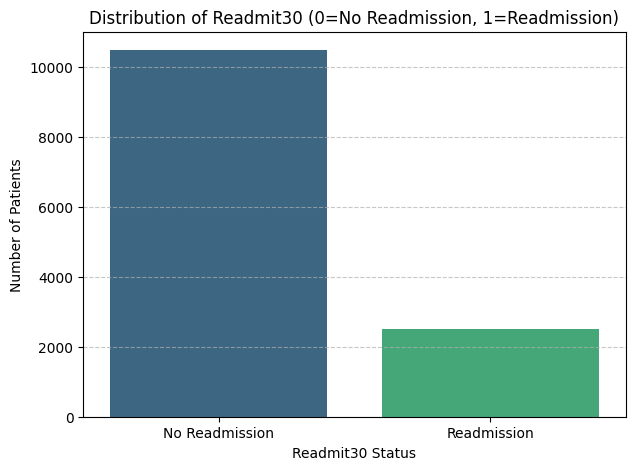

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Readmit30', data=df, palette='viridis', hue='Readmit30', legend=False)
plt.title('Distribution of Readmit30 (0=No Readmission, 1=Readmission)')
plt.xlabel('Readmit30 Status')
plt.ylabel('Number of Patients')
plt.xticks(ticks=[0, 1], labels=['No Readmission', 'Readmission'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Correlation Matrix of Numerical Features

To identify potential relationships between numerical variables, we'll calculate the correlation matrix and visualize it using a heatmap. This can highlight strong positive or negative correlations.

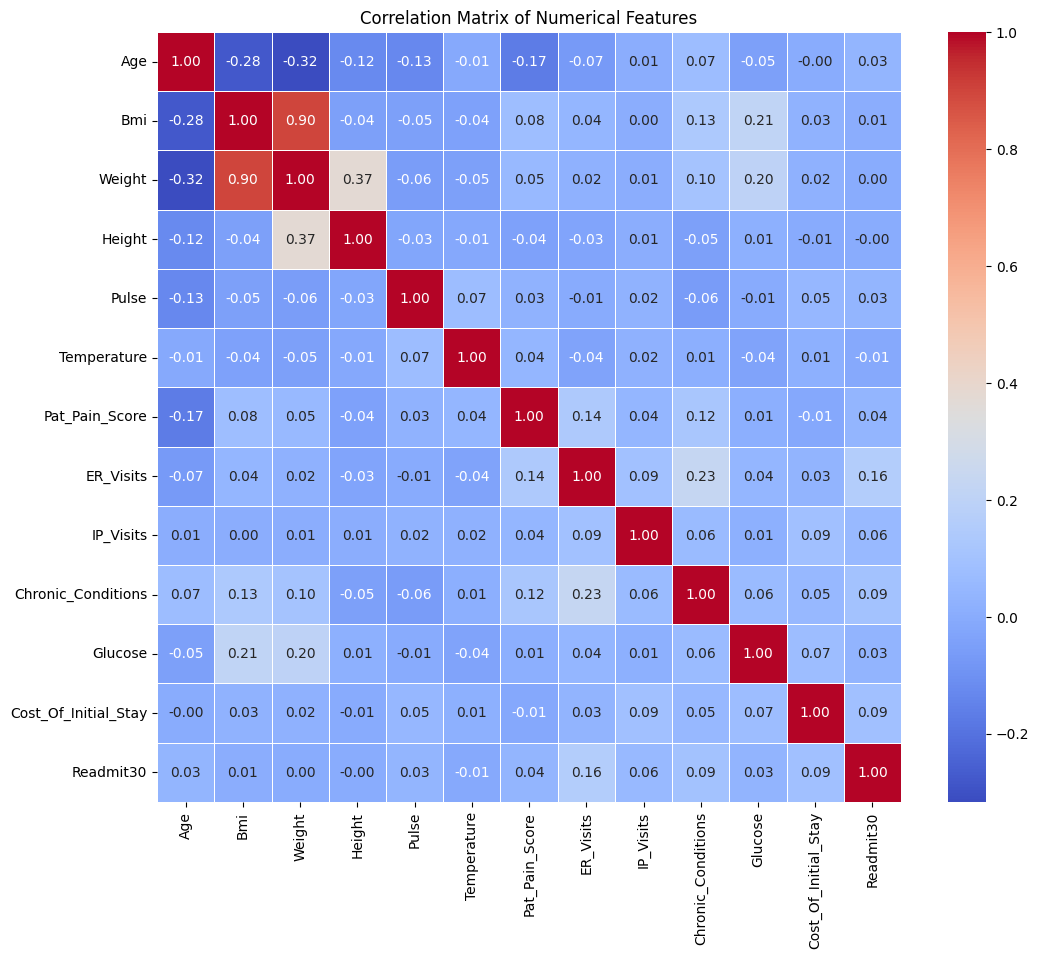

In [ ]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Feature Importance Visualization

To understand which features are most influential in predicting `Readmit30`, we will train a RandomForestClassifier and visualize its feature importances.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a RandomForestClassifier model
# Using random_state for reproducibility
# Class_weight='balanced' to handle the class imbalance
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on the training data
model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


/tmp/ipykernel_13396/4011568778.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='viridis')


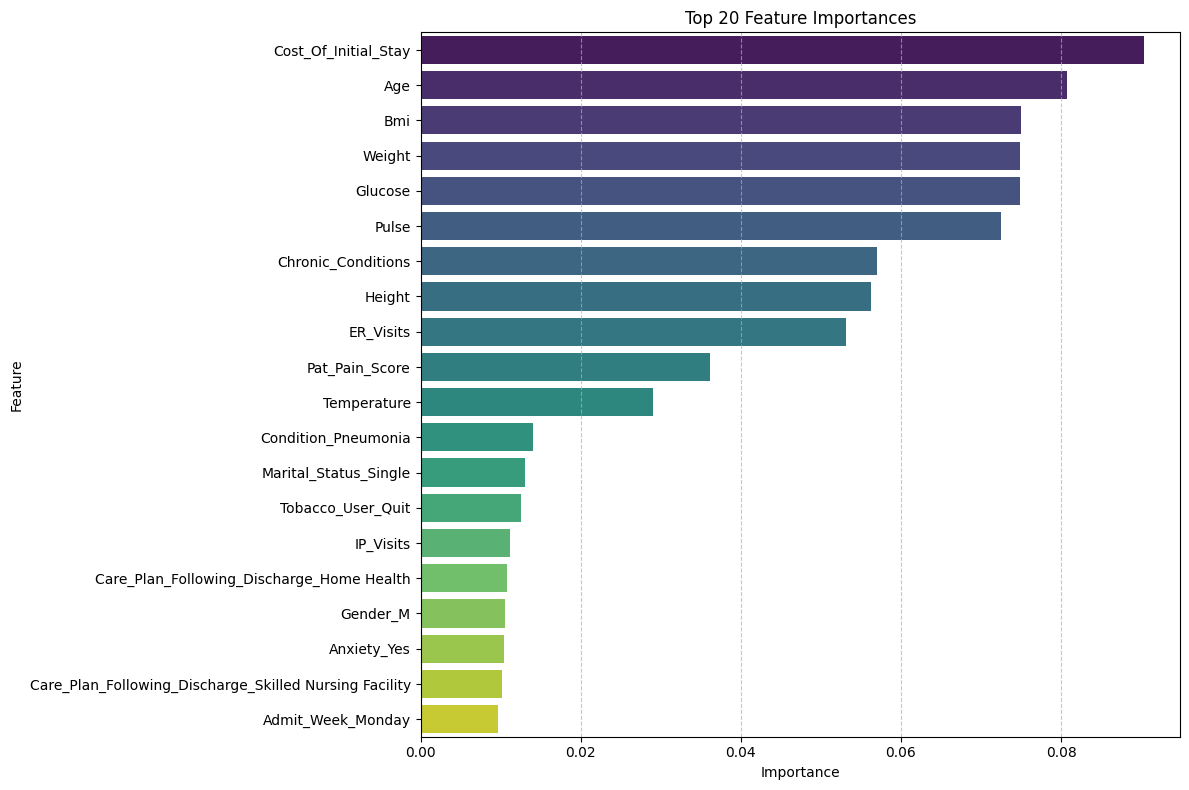

In [ ]:
# Get feature importances from the trained model
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order and select the top N
top_n_features = 20 # You can adjust this number as needed
sorted_feature_importances = feature_importances.sort_values(ascending=False).head(top_n_features)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='viridis')
plt.title(f'Top {top_n_features} Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
plt.savefig('feature_importance.png', bbox_inches='tight')
print("Feature importance plot saved as 'feature_importance.png'")

Feature importance plot saved as 'feature_importance.png'


<Figure size 640x480 with 0 Axes>

In [ ]:
# Export the correlation matrix to a CSV file
correlation_matrix.to_csv('correlation_matrix.csv', index=True)
print("Correlation matrix exported to 'correlation_matrix.csv'")

Correlation matrix exported to 'correlation_matrix.csv'


### Encoding Categorical Variables

To prepare the data for machine learning models, we need to convert categorical features into a numerical format. One-hot encoding is a common technique for this, where each category is transformed into a new binary column. We'll apply this to all non-numerical columns in our DataFrame.

In [ ]:
# Select categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame after encoding:", df_encoded.shape)
display(df_encoded.head())

Shape of DataFrame after encoding: (12980, 52)


,Age,Bmi,Weight,Height,Pulse,Temperature,Pat_Pain_Score,ER_Visits,IP_Visits,Chronic_Conditions,...,Diabetes_Yes,Anxiety_Yes,Obesity_Yes,Dementia_Yes,Condition_Pneumonia,Care_Plan_Following_Discharge_Expired,Care_Plan_Following_Discharge_Home Health,Care_Plan_Following_Discharge_Hospice,Care_Plan_Following_Discharge_Skilled Nursing Facility,Care_Plan_Following_Discharge_Telehealth
0,76.6,45.89,243.0,61.0,75,98.0,0,5,0,8,...,False,False,False,True,True,False,False,False,True,False
1,81.6,29.44,182.0,66.0,100,98.0,2,0,0,7,...,False,False,False,False,True,False,False,False,False,True
2,87.9,20.51,102.0,59.0,76,98.0,0,0,0,6,...,False,False,False,False,False,False,False,False,True,False
3,74.3,26.93,172.0,67.0,62,99.0,0,3,0,7,...,False,False,False,False,False,False,False,False,False,True
4,37.3,33.72,235.0,70.0,83,98.0,0,0,0,2,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('Readmit30', axis=1)
y = df_encoded['Readmit30']

# Split the data into training and testing sets
# Using a common split ratio of 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (10384, 51)
Shape of y_train: (10384,)
Shape of X_test: (2596, 51)
Shape of y_test: (2596,)


Now that the data is split, let's check for class imbalance in the training set's target variable (`y_train`).

In [ ]:
print("Class distribution in y_train:")
display(y_train.value_counts())

print("Class distribution percentage in y_train:")
display(y_train.value_counts(normalize=True) * 100)

Class distribution in y_train:


,count
Readmit30,
0,8386
1,1998


Class distribution percentage in y_train:


,proportion
Readmit30,
0,80.75886
1,19.24114
